
# Investigate Topic Names
Load topic_name, topic_description, and confidence from MongoDB.


In [2]:
from __future__ import annotations
import sys
from pathlib import Path
import pandas as pd

repo_root = Path.cwd().resolve()
for parent in [repo_root] + list(repo_root.parents):
    if (parent / "db" / "store.py").exists():
        repo_root = parent
        break
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

from db.store import connect_from_config

store = connect_from_config()
try:
    pipeline = [
        {"$match": {"topic_id": {"$nin": [None, ""]}}},
        {"$group": {
            "_id": "$topic_id",
            "topic_name": {"$first": "$topic_name"},
            "topic_description": {"$first": "$topic_description"},
            "confidence": {"$first": "$confidence"}
        }},
        {"$sort": {"_id": 1}}
    ]
    rows = list(store.posts.aggregate(pipeline))
finally:
    store.close()

df = pd.DataFrame(rows).rename(columns={"_id": "topic_id"})
df


,topic_id,topic_name,topic_description,confidence
0,noise,Healthcare Policy and Economics,"Posts discuss public health interventions, vac...",0.80
1,noise_1,Consumer Electronics Hardware,This topic covers consumer electronics hardwar...,0.85
2,noise_10,AI Hallucination Mechanisms,This topic covers the fundamental nature of AI...,0.95
3,noise_11,AI Market Sentiment and Future,This topic explores public and professional se...,0.92
4,noise_12,Government AI Policy and Geopolitics,This topic focuses on the intersection of gove...,0.94
5,noise_13,AI Trust and Human Identity,This topic covers the erosion of trust in onli...,0.92
6,noise_14,AI Impact on Software Engineering,This topic covers discussions about how AI too...,0.95
7,noise_15,AI in Creative Arts and Copyright,This topic focuses on the intersection of AI a...,0.92
8,noise_2,DIY Electronics and Lab Experiments,This topic focuses on hands-on electronics and...,0.90
9,noise_3,Environmental and Industrial Impacts,This topic covers the environmental effects of...,0.85


In [1]:
from db.store import connect_from_config

store = connect_from_config()
result = store.posts.update_many(
    {"topic_id": "noise"},
    {"$unset": {"topic_name": "", "topic_description": "", "confidence": ""}},
)
print("updated:", result.modified_count)
store.close()


ModuleNotFoundError: No module named 'db'

In [3]:
import math
from collections import Counter, defaultdict

import numpy as np
import pandas as pd

from db.store import connect_from_config
from reddit.reddit_cleaner import build_topic_text

def estimate_tokens(text: str) -> int:
    text = (text or "").strip()
    if not text:
        return 0
    return max(1, int(math.ceil(len(text) / 4)))

def get_post_text(doc: dict) -> str:
    text = (doc.get("topic_text") or "").strip()
    if text:
        return text
    title = doc.get("title") or ""
    selftext = doc.get("selftext") or ""
    return build_topic_text(title, selftext, bool(selftext))

def get_comment_text(doc: dict) -> str:
    return (
        doc.get("comment_text_clean")
        or doc.get("comment_text")
        or doc.get("body_clean")
        or doc.get("body")
        or ""
    )

store = connect_from_config()
try:
    # Posts
    post_tokens = {}
    for doc in store.posts.find(
        {}, {"_id": 0, "post_id": 1, "topic_text": 1, "title": 1, "selftext": 1}
    ):
        post_id = doc.get("post_id")
        if not post_id:
            continue
        post_text = get_post_text(doc)
        post_tokens[str(post_id)] = estimate_tokens(post_text)

    # Comments
    comment_counts = Counter()
    comment_tokens = defaultdict(int)

    for doc in store.comments.find(
        {}, {"_id": 0, "post_id": 1, "comment_text_clean": 1, "comment_text": 1, "body_clean": 1, "body": 1}
    ):
        post_id = doc.get("post_id")
        if not post_id:
            continue
        post_id = str(post_id)
        comment_counts[post_id] += 1
        comment_text = get_comment_text(doc).strip()
        if comment_text:
            comment_tokens[post_id] += estimate_tokens(comment_text)

finally:
    store.close()

rows = []
for post_id, tok_post in post_tokens.items():
    c_count = comment_counts.get(post_id, 0)
    tok_total = tok_post + comment_tokens.get(post_id, 0)
    rows.append(
        {"post_id": post_id, "comment_count": c_count, "token_count": tok_total}
    )

stats_df = pd.DataFrame(rows)

# Verteilung: wie viele Posts haben wie viele Comments
distribution = (
    stats_df["comment_count"]
    .value_counts()
    .sort_index()
    .reset_index()
    .rename(columns={"index": "comment_count", "comment_count": "post_count"})
)

avg_comments = stats_df["comment_count"].mean()
avg_tokens = stats_df["token_count"].mean()

display(distribution.head(30))
print(f"Avg comments per post: {avg_comments:.2f}")
print(f"Avg tokens per post (post+comments): {avg_tokens:.1f}")


,post_count,count
0,10,193
1,11,169
2,12,160
3,13,120
4,14,99
5,15,96
6,16,86
7,17,92
8,18,68
9,19,62


Avg comments per post: 36.93
Avg tokens per post (post+comments): 2121.4


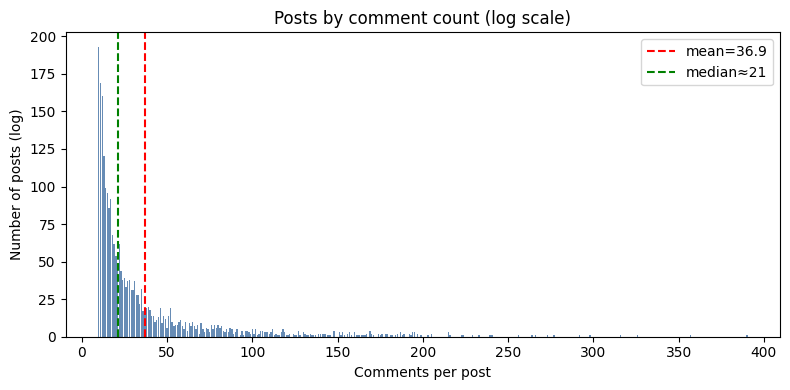

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Falls die Spalten anders heißen, umbenennen
if "comment_count" not in distribution.columns:
    if {"post_count", "count"}.issubset(distribution.columns):
        distribution = distribution.rename(
            columns={"post_count": "comment_count", "count": "post_count"}
        )
    else:
        # Fallback: erste zwei Spalten nehmen
        distribution = distribution.rename(
            columns={distribution.columns[0]: "comment_count", distribution.columns[1]: "post_count"}
        )

distribution = distribution.sort_values("comment_count")
distribution["comment_count"] = distribution["comment_count"].astype(int)
distribution["post_count"] = distribution["post_count"].astype(int)

x = distribution["comment_count"].values
y = distribution["post_count"].values

total_posts = y.sum()
mean_comments = (x * y).sum() / total_posts
cdf = np.cumsum(y)
median_comments = x[np.searchsorted(cdf, total_posts * 0.5)]

plt.figure(figsize=(8, 4))
plt.bar(x, y, color="#4C78A8", alpha=0.85)
#plt.yscale("log")
plt.axvline(mean_comments, color="red", linestyle="--", linewidth=1.5, label=f"mean={mean_comments:.1f}")
plt.axvline(median_comments, color="green", linestyle="--", linewidth=1.5, label=f"median≈{median_comments:.0f}")
plt.title("Posts by comment count (log scale)")
plt.xlabel("Comments per post")
plt.ylabel("Number of posts (log)")
plt.legend()
plt.tight_layout()
plt.show()
